In [366]:
# Importing all necessary libraries.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles, make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import accuracy_score
import seaborn as sns

In [367]:
# Reset the PN sequence generator.
seed = 42
np.random.seed(seed)

## 1. Gerando os dados de 3 classes.

A matrix $\textbf{X}$ retornada pela função `create_dataset` tem dimensões $N \times K$, onde $K=2$, ou seja, atributos $x_1$ e $x_2$.

In [368]:
def create_dataset(n_circle=667,
                   n_moons=666,
                   moon_distance=3.0,
                   noise=0.05,
                   random_state=42):

    # ---------------------------
    # 1) Círculo central
    # ---------------------------
    Xc, yc = make_circles(n_samples=n_circle,
                          factor=0.75,
                          noise=noise,
                          random_state=random_state)

    # usar apenas o círculo externo
    Xc = Xc[yc == 1]
    yc = np.zeros(len(Xc), dtype=int)

    # ---------------------------
    # 2) Duas meias-luas
    # ---------------------------
    Xm, ym = make_moons(n_samples=n_moons,
                        noise=noise,
                        random_state=random_state)

    # separar as duas luas
    moon1 = Xm[ym == 0]
    moon2 = Xm[ym == 1]

    # deslocar verticalmente (distância ajustável)
    moon1[:,1] += moon_distance - 0.5
    moon2[:,1] -= moon_distance

    # garantir que fiquem centradas em x=0
    moon1[:,0] -= np.mean(moon1[:,0])
    moon2[:,0] -= np.mean(moon2[:,0])

    # rótulos
    y1 = np.ones(len(moon1), dtype=int)
    y2 = np.full(len(moon2), 2, dtype=int)

    # ---------------------------
    # 3) Juntar tudo
    # ---------------------------
    X = np.vstack([Xc, moon1, moon2])
    y = np.concatenate([yc, y1, y2])

    return X, y

X, y = create_dataset(moon_distance=1.0, random_state=seed)

### Plotando as 3 classes.

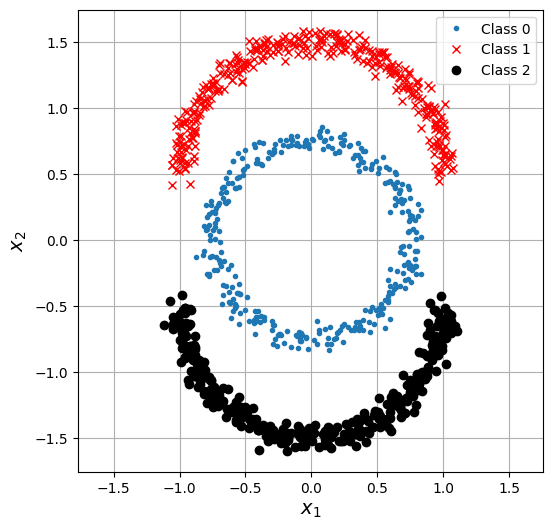

In [369]:
idx0 = np.argwhere(y == 0)
idx1 = np.argwhere(y == 1)
idx2 = np.argwhere(y == 2)

fig = plt.figure(figsize=(6,6))
plt.plot(X[idx0,0], X[idx0,1], '.', label='Class 0')
plt.plot(X[idx1,0], X[idx1,1], 'rx', label='Class 1')
plt.plot(X[idx2,0], X[idx2,1], 'ko', label='Class 2')
plt.xlabel('$x_1$', fontsize=14)
plt.ylabel('$x_2$', fontsize=14)
plt.axis("equal")
plt.legend()
plt.grid()
plt.show()

## 2. Dividindo os dados em conjuntos de treinamento e validação.

In [370]:
# Divide o dataset em treinamento e teste
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.25, random_state=seed)

## 3. Validação cruzada: k-fold

**Observações**:

+ A classe `LogisticRegression` implementa o **regressor softmax** quando o número de classes é maior do que 2 ($Q > 2$).

+ A classe `LogisticRegression` aplica regularização L2 por padrão, que pode ser desabilitada com o parâmetro `penalty=None`.

+ A regularização L2 evita que um modelo muito complexo se sobreajuste aos dados de treinamento.

+ Porém, como queremos identificar o sobreajuste, deixamos a regularização desabilitada.


In [371]:
# Ordem de polinômios de 1 a 10
degrees = list(range(1, 11))

train_acc = []
val_acc = []

# KFold
k = 10
kf = KFold(n_splits=k, shuffle=True, random_state=seed)

for deg in degrees:
    # armazenar erro médio por fold
    fold_train_acc = []
    fold_val_acc = []

    for train_idx, val_idx in kf.split(X_train_full):
        X_train = X_train_full[train_idx]
        y_train = y_train_full[train_idx]
        X_val = X_train_full[val_idx]
        y_val = y_train_full[val_idx]

        # Pipeline: padronização + polinômio + regressor logístico
        model = make_pipeline(
            PolynomialFeatures(degree=deg, include_bias=False), # include_bias já é feito pelo LogisticRegression
            StandardScaler(),
            LogisticRegression(penalty=None, random_state=seed)
        )

        # Treinar
        model.fit(X_train, y_train)

        # Prever
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)

        # Calcular acurácia
        fold_train_acc.append(accuracy_score(y_train, y_train_pred))
        fold_val_acc.append(accuracy_score(y_val, y_val_pred))

    # Média dos folds
    train_acc.append(np.mean(fold_train_acc))
    val_acc.append(np.mean(fold_val_acc))

## 4. Apresentação dos resultados da validação cruzada

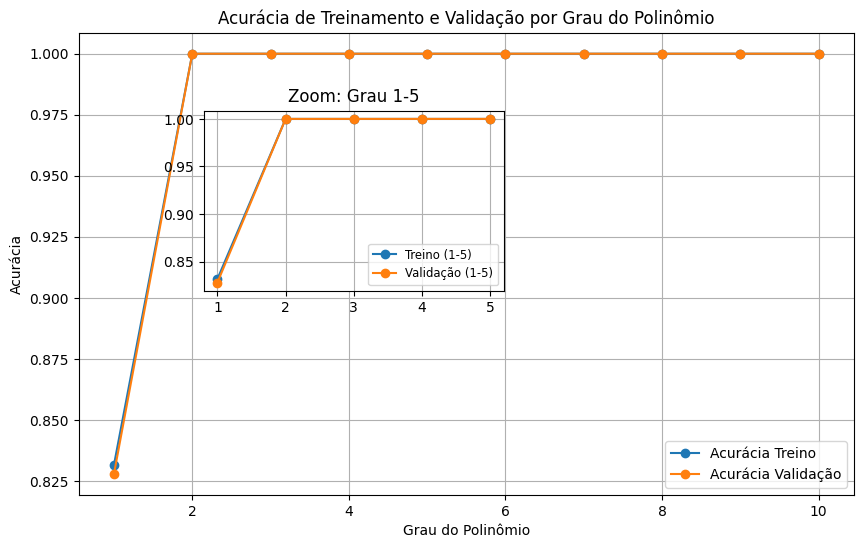

In [372]:
# Plot do erro vs grau do polinômio
fig, ax_main = plt.subplots(figsize=(10, 6))

# gráfico principal (1 a 30)
ax_main.plot(degrees, train_acc, label='Acurácia Treino', marker='o')
ax_main.plot(degrees, val_acc, label='Acurácia Validação', marker='o')
ax_main.set_xlabel('Grau do Polinômio')
ax_main.set_ylabel('Acurácia')
ax_main.set_title('Acurácia de Treinamento e Validação por Grau do Polinômio')
ax_main.legend()
ax_main.grid(True)

# inset para ordens 1 a 5
left, bottom, width, height = [0.25, 0.45, 0.3, 0.3]  # posição na figura (relativo)
ax_inset = fig.add_axes([left, bottom, width, height])

# selecionar apenas indices 1 a 5
idx_small = [i for i, deg in enumerate(degrees) if deg <= 5]
small_deg = [degrees[i] for i in idx_small]
small_train_acc = [train_acc[i] for i in idx_small]
small_val_acc = [val_acc[i] for i in idx_small]

ax_inset.plot(small_deg, small_train_acc, label='Treino (1-5)', marker='o')
ax_inset.plot(small_deg, small_val_acc, label='Validação (1-5)', marker='o')
ax_inset.set_title('Zoom: Grau 1-5')
ax_inset.set_xticks(small_deg)
ax_inset.grid(True)
ax_inset.legend(fontsize='small')

plt.show()

## 5. Melhor grau

In [373]:
# Melhor grau
best_degree = degrees[np.argmax(val_acc)]
print(f"Melhor grau de polinômio segundo a validação: {best_degree}")

Melhor grau de polinômio segundo a validação: 2


## 6. Resultado final

In [374]:
# Treinar esse melhor modelo com todo o conjunto de treino
best_model = make_pipeline(
    PolynomialFeatures(degree=best_degree, include_bias=False),
    StandardScaler(),
    LogisticRegression(penalty=None, random_state=seed)
)
best_model.fit(X_train_full, y_train_full)

# Avaliar no conjunto de teste
y_test_pred = best_model.predict(X_test)
test_error = accuracy_score(y_test, y_test_pred)
print(f"Acurácia no conjunto de teste com grau {best_degree}: {test_error:.4f}")

Acurácia no conjunto de teste com grau 2: 1.0000


## 7. Plotando as regiões de decisão.


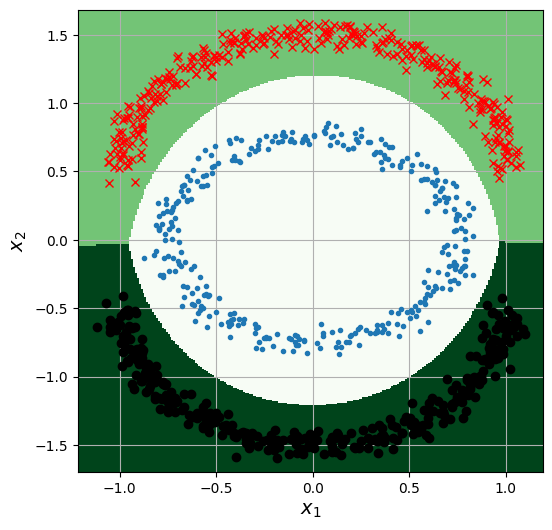

In [375]:
# Plot the decision boundary. For that, we will assign a color to each
# point in the mesh [x_min, x_max]x[y_min, y_max].
x_min, x_max = X[:, 0].min() - .1, X[:, 0].max() + .1
y_min, y_max = X[:, 1].min() - .1, X[:, 1].max() + .1
h = .01  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# This attribute matrix must also follow the same shape
# as the one created for the training.
attribute_matrix = np.c_[xx.ravel(), yy.ravel()]

# Probabilities as output.
Z = best_model.predict(attribute_matrix)

# Put the result into a color plot.
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,6))
plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Greens, shading='auto')

# Plot also the training points.
plt.plot(X[idx0,0], X[idx0,1], '.', label='Class 0')
plt.plot(X[idx1,0], X[idx1,1], 'rx', label='Class 1')
plt.plot(X[idx2,0], X[idx2,1], 'ko', label='Class 2')
plt.xlabel('$x_1$', fontsize=14)
plt.ylabel('$x_2$', fontsize=14)

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.grid()

plt.show()